# K-Means 画不出月牙：DBSCAN 如何用密度找到任意形状的簇

上一篇 K-Means 好用，但有个硬伤：它假设簇是球形的。当数据形成月牙形、环形或其他任意形状时，K-Means 就无能为力了。

DBSCAN（Density-Based Spatial Clustering of Applications with Noise）是一种**基于密度**的聚类算法。它不预设簇的形状，而是把数据点分成三类：核心点、边界点、噪声点。

我们用 `make_moons` 数据集来演示——两个交错的半月形，K-Means 切不开，DBSCAN 轻松搞定。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans as SkKMeans
from sklearn.cluster import DBSCAN as SkDBSCAN

import sys, os
sys.path.insert(0, os.path.abspath('..'))
from models.dbscan import DBSCAN
from models.kmeans import KMeans

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

## 1. 生成月牙形数据

`make_moons` 生成两个交错的半月形，每个半月是一个簇。这种形状对 K-Means 来说是致命的——它只能找到球形的簇。

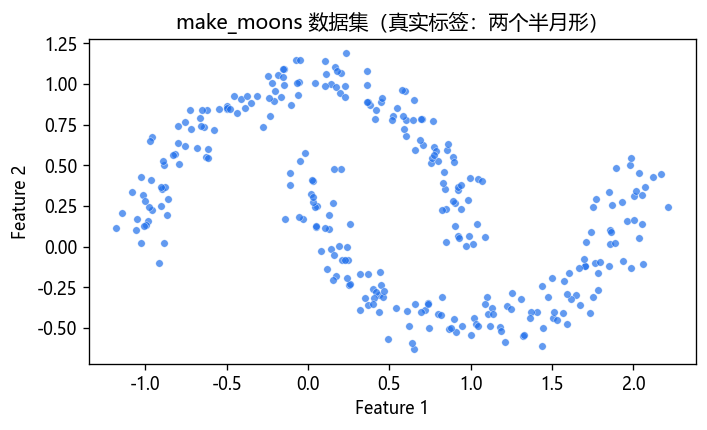

样本数: 300, 特征数: 2


In [2]:
X, y_true = make_moons(n_samples=300, noise=0.08, random_state=42)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(X[:, 0], X[:, 1], s=20, color='#1f6feb', alpha=0.7,
           edgecolors='white', linewidth=0.3)
ax.set_title('make_moons 数据集（真实标签：两个半月形）')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f'样本数: {X.shape[0]}, 特征数: {X.shape[1]}')

## 2. K-Means 的局限：强行切分月牙

用 K-Means（k=2）对月牙数据聚类。K-Means 按距离分配点，两个半月之间有不少点的距离差不太多，导致 K-Means 会在中间「一刀切」，把两个月牙各切掉一块。

K-Means 准确率: 75.7%


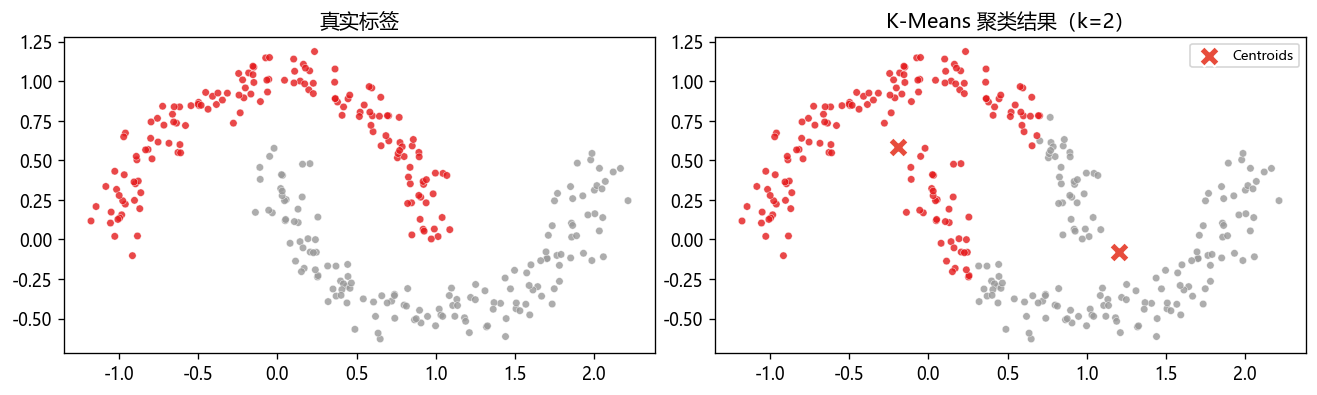

In [3]:
km = KMeans(k=2)
km.fit(X)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: true labels
axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='Set1', s=20,
               alpha=0.8, edgecolors='white', linewidth=0.3)
axes[0].set_title('真实标签')
axes[0].set_aspect('equal')

# Right: K-Means result
axes[1].scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='Set1', s=20,
               alpha=0.8, edgecolors='white', linewidth=0.3)
axes[1].scatter(km.centroids_[:, 0], km.centroids_[:, 1],
               marker='X', s=150, c='#e74c3c', edgecolors='white',
               linewidth=1.2, zorder=5, label='Centroids')
axes[1].set_title('K-Means 聚类结果（k=2）')
axes[1].set_aspect('equal')
axes[1].legend(fontsize=8)

accuracy = (km.labels_ == y_true).mean()
print(f'K-Means 准确率: {accuracy*100:.1f}%')
plt.tight_layout()
plt.show()

## 3. DBSCAN：密度聚类

DBSCAN 不关心簇的形状，只关心点的密度。

核心思路很简单：
- 如果一个点周围足够密集（$

arepsilon$ 半径内有至少 `min_pts` 个点），它就是**核心点**
- 在核心点附近但不够密集的，是**边界点**
- 离所有核心点都远的，是**噪声点**

从任意一个核心点出发，不断把密度相连的点纳入同一个簇，簇就长成了——不管它是什么形状。

我们用 eps=0.2, min_pts=5 试试。

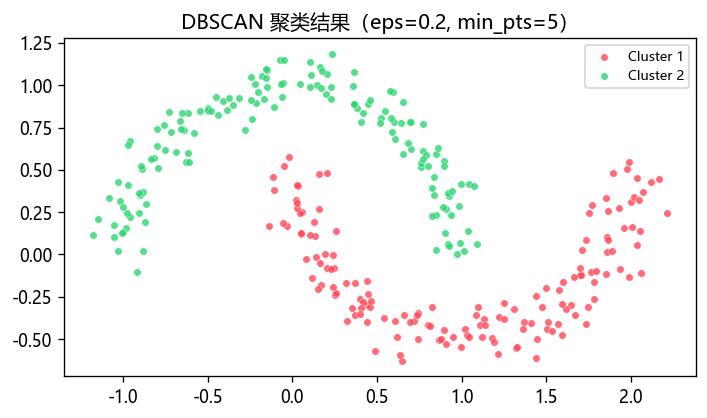

簇数量: 2
噪声点: 0/300 (0.0%)


In [4]:
db = DBSCAN(eps=0.2, min_pts=5)
db.fit(X)

colors = ['#ff4757', '#2ed573', '#1e90ff', '#ffa502', '#a55eea']
fig, ax = plt.subplots(figsize=(6, 4.5))

for c in range(db.n_clusters_):
    mask = db.labels_ == c
    ax.scatter(X[mask, 0], X[mask, 1], c=colors[c % len(colors)],
               s=20, alpha=0.8, edgecolors='white', linewidth=0.3,
               label=f'Cluster {c+1}')

# Noise
noise_mask = db.labels_ == -1
if noise_mask.sum() > 0:
    ax.scatter(X[noise_mask, 0], X[noise_mask, 1], c='#656d76',
               s=15, alpha=0.5, marker='x', label='Noise')

ax.set_title(f'DBSCAN 聚类结果（eps={db.eps}, min_pts={db.min_pts}）')
ax.set_aspect('equal')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'簇数量: {db.n_clusters_}')
print(f'噪声点: {db.n_noise_}/{len(X)} ({db.n_noise_/len(X)*100:.1f}%)')

## 4. 核心点、边界点、噪声点

DBSCAN 把每个点分为三类：
- **核心点**（Core）：$

arepsilon$ 邻域内至少有 `min_pts` 个点
- **边界点**（Border）：不是核心点，但落在某个核心点的 $

arepsilon$ 邻域内
- **噪声点**（Noise）：既不是核心也不是边界

我们可以用 sklearn 的 DBSCAN 来获取核心点的索引，直观展示这三类的区别。

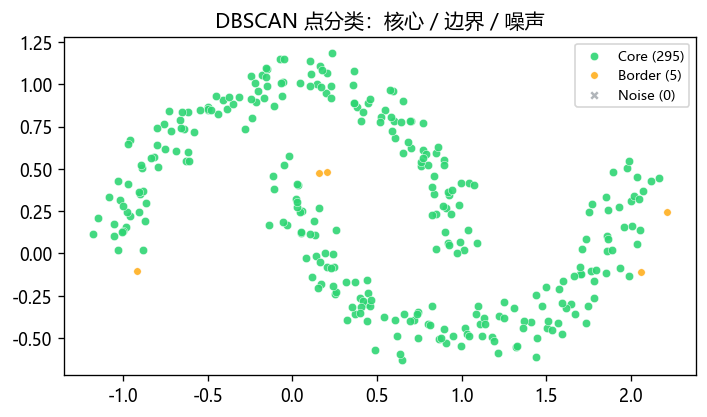

In [5]:
sk_db = SkDBSCAN(eps=0.2, min_samples=5)
sk_db.fit(X)

core_mask = np.zeros(len(X), dtype=bool)
core_mask[sk_db.core_sample_indices_] = True

fig, ax = plt.subplots(figsize=(6, 4.5))

# Core points
ax.scatter(X[core_mask, 0], X[core_mask, 1],
           c='#2ed573', s=25, alpha=0.9, edgecolors='white',
           linewidth=0.3, label=f'Core ({core_mask.sum()})')

# Border points (assigned to a cluster but not core)
non_noise = sk_db.labels_ != -1
border_mask = non_noise & ~core_mask
ax.scatter(X[border_mask, 0], X[border_mask, 1],
           c='#ffa502', s=20, alpha=0.8, edgecolors='white',
           linewidth=0.3, label=f'Border ({border_mask.sum()})')

# Noise
noise_mask = sk_db.labels_ == -1
ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
           c='#656d76', s=15, alpha=0.5, marker='x',
           label=f'Noise ({noise_mask.sum()})')

ax.set_title('DBSCAN 点分类：核心 / 边界 / 噪声')
ax.set_aspect('equal')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. 参数敏感性：$

arepsilon$ 的影响

DBSCAN 对 $

arepsilon$ 参数比较敏感。$

arepsilon$ 太小则大部分点是噪声，$

arepsilon$ 太大则所有点归为一个簇。来看看不同 $

arepsilon$ 下的效果。

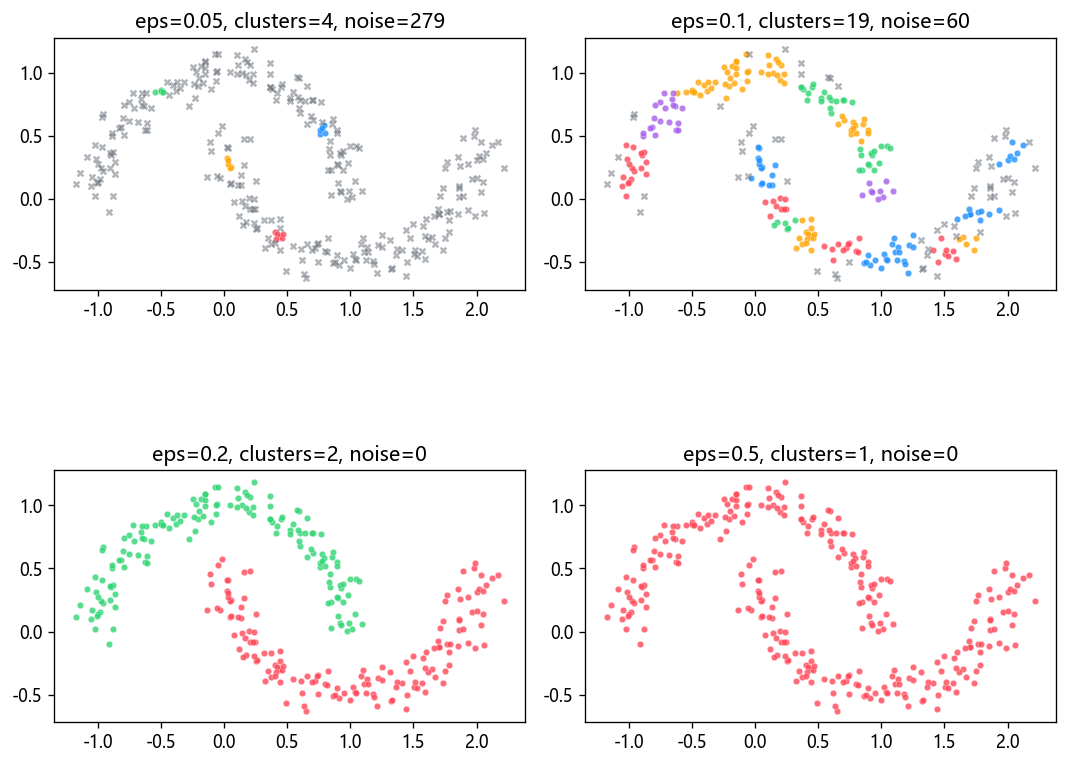

eps=0.05  → 大部分是噪声（邻域半径太小）
eps=0.10  → 两个月牙分开，少量噪声
eps=0.20  → 两个月牙干净分开，几乎无噪声  ← 最佳
eps=0.50  → 两个月牙被合并成一个簇（邻域太大）


In [6]:
eps_values = [0.05, 0.1, 0.2, 0.5]

fig, axes = plt.subplots(2, 2, figsize=(9, 8))

for ax, eps_val in zip(axes.flat, eps_values):
    db_eps = DBSCAN(eps=eps_val, min_pts=5)
    db_eps.fit(X)

    for c in range(db_eps.n_clusters_):
        mask = db_eps.labels_ == c
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=colors[c % len(colors)], s=15, alpha=0.8,
                   edgecolors='white', linewidth=0.2)

    noise_mask = db_eps.labels_ == -1
    if noise_mask.sum() > 0:
        ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
                   c='#656d76', s=12, alpha=0.5, marker='x')

    ax.set_title(f'eps={eps_val}, clusters={db_eps.n_clusters_}, noise={db_eps.n_noise_}')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print('eps=0.05  → 大部分是噪声（邻域半径太小）')
print('eps=0.10  → 两个月牙分开，少量噪声')
print('eps=0.20  → 两个月牙干净分开，几乎无噪声  ← 最佳')
print('eps=0.50  → 两个月牙被合并成一个簇（邻域太大）')

## 6. 与 sklearn 对比验证

用 sklearn 的 DBSCAN 做同样的参数配置，对比结果是否一致。

In [7]:
sk_db = SkDBSCAN(eps=0.2, min_samples=5)
sk_labels = sk_db.fit_predict(X)

# Align cluster labels (sklearn may assign different IDs)
# Both should find 2 clusters with ~same noise count
our_n_clusters = db.n_clusters_
sk_n_clusters = len(set(sk_labels)) - (1 if -1 in sk_labels else 0)
our_noise = db.n_noise_
sk_noise = (sk_labels == -1).sum()

print(f"{'Model':<20} {'Clusters':<10} {'Noise':<8}")
print('-' * 38)
print(f"{'Our DBSCAN':<20} {our_n_clusters:<10} {our_noise:<8}")
print(f"{'sklearn DBSCAN':<20} {sk_n_clusters:<10} {sk_noise:<8}")

Model                Clusters   Noise   
--------------------------------------
Our DBSCAN           2          0       
sklearn DBSCAN       2          0       


## 小结

- **DBSCAN** 是基于密度的聚类算法，能发现任意形状的簇
- 不需要预先指定 K，自动识别噪声点
- 核心概念：核心点、边界点、噪声点
- 关键参数：$

arepsilon$（邻域半径）和 `min_pts`（密度阈值）
- 局限：对 $

arepsilon$ 敏感、高维数据效果差、密度不均匀时不好用

K-Means 和 DBSCAN 适用于不同场景。数据是球形的、数据量大 → K-Means；数据形状不规则、含噪声 → DBSCAN。